# 03 - Clustering: zaman kullanim profilleri
K-Means, once standardize. k elbow + silhouette ile secilir.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from src.config import CATEGORIES
df = pd.read_csv("../data/processed/timeuse.csv")
note = " (SENTETIK VERI)" if df["synthetic"].iloc[0] else ""
X = StandardScaler().fit_transform(df[CATEGORIES])

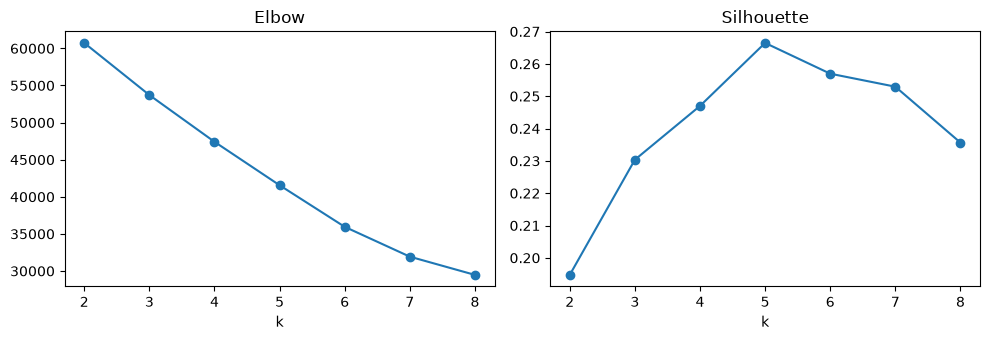

Secilen k: 5


In [2]:
ks = range(2, 9)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    inertia.append(km.inertia_); sil.append(silhouette_score(X, km.labels_, sample_size=2000, random_state=0))
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(ks, inertia, "o-"); ax[0].set_title("Elbow"); ax[0].set_xlabel("k")
ax[1].plot(ks, sil, "o-"); ax[1].set_title("Silhouette"); ax[1].set_xlabel("k")
plt.tight_layout(); plt.savefig("../figures/04_choose_k.png", dpi=150); plt.show()
K = int(list(ks)[int(np.argmax(sil))]); print("Secilen k:", K)

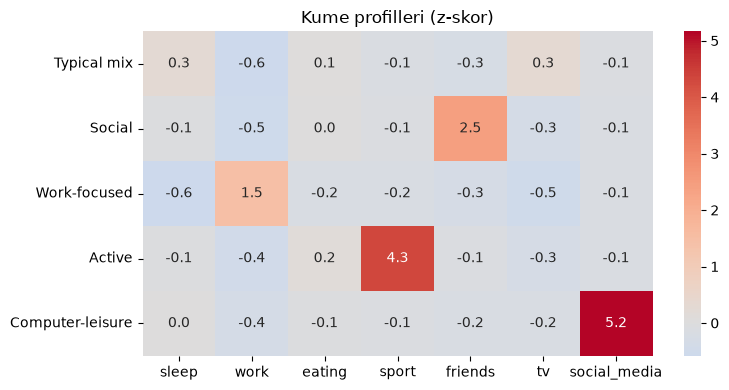

In [4]:
km = KMeans(n_clusters=K, n_init=10, random_state=0).fit(X)
df["cluster_id"] = km.labels_
z = pd.DataFrame(km.cluster_centers_, columns=CATEGORIES)

LABELS = {"work": "Work-focused", "friends": "Social", "sleep": "Sleep-heavy",
          "tv": "Screen-heavy", "social_media": "Computer-leisure",
          "sport": "Active", "eating": "Food-focused"}
names = {i: ("Typical mix" if z.loc[i].max() < 1 else LABELS[z.loc[i].idxmax()]) for i in z.index}
seen = {}
for i, n in names.items():
    seen[n] = seen.get(n, 0) + 1
    if seen[n] > 1:
        names[i] = f"{n} #{seen[n]}"
df["cluster"] = df["cluster_id"].map(names)
z.index = [names[i] for i in z.index]

plt.figure(figsize=(8, 4))
sns.heatmap(z, annot=True, fmt=".1f", cmap="coolwarm", center=0)
plt.title("Kume profilleri (z-skor)" + note); plt.tight_layout()
plt.savefig("../figures/05_cluster_profiles.png", dpi=150); plt.show()

In [5]:
profile_hours = df.groupby("cluster")[CATEGORIES].mean().round(1)
profile_hours["n"] = df["cluster"].value_counts()
df.to_csv("../data/processed/timeuse_clustered.csv", index=False)
profile_hours

,sleep,work,eating,sport,friends,tv,social_media,n
cluster,,,,,,,,
Active,8.7,0.8,1.3,4.4,0.6,2.1,0.1,336
Computer-leisure,8.8,1.1,1.1,0.2,0.5,2.5,4.2,222
Social,8.7,0.4,1.2,0.2,4.4,2.0,0.1,1011
Typical mix,9.4,0.2,1.2,0.2,0.3,3.9,0.1,5962
Work-focused,7.6,8.4,1.0,0.1,0.3,1.5,0.1,2847
